# testing on tmQMg structures

In [1]:
import rxembed as rx
import xyzrender as xr

tmQMg_path = '../../tmQMg/data/xyz/'

Using JAFWIX.xyz


!!! Warning !!! Distance between atoms 3 and 2 (0.974078 A) is suspicious.
!!! Warning !!! Distance between atoms 3 and 2 (0.975004 A) is suspicious.


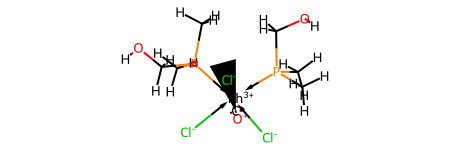

CX SMI: C[P](C)(CO)->[Rh+3](<-[Cl-])(<-[Cl-])(<-[Cl-])(<-[C-]#[O+])<-[P](C)(C)CO |atomProp:1.atomNote.s0:5.atomNote.OCT:6.atomNote.s1:7.atomNote.s3:8.atomNote.s4:9.atomNote.s5:11.atomNote.s2|
  idx  centres (geometry label [slots] Δ/Λ/-)  ligand
  [ 0] Rh0 OCT fac [Cl2 C11 Cl1 P4 Cl3 P5] -  -
       Rh0 trans: Cl2-C11, Cl1-P4, Cl3-P5
  [ 1] Rh0 OCT mer [Cl1 Cl2 Cl3 P4 P5 C11] -  -
       Rh0 trans: Cl1-Cl2, Cl3-P4, P5-C11
  [ 2] Rh0 OCT mer [Cl1 Cl2 Cl3 C11 P4 P5] -  -
       Rh0 trans: Cl1-Cl2, Cl3-C11, P4-P5
M–L RMSD = 2.233 Å
CXSMILES match for  Rh0 OCT fac [Cl2 C11 Cl1 P4 Cl3 P5] -  -


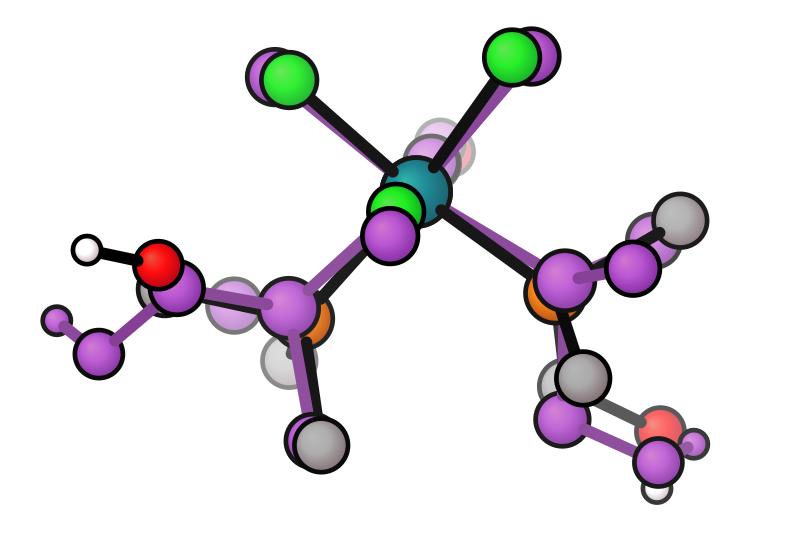

M–L RMSD = 1.704 Å
CXSMILES mismatch for  Rh0 OCT mer [Cl1 Cl2 Cl3 P4 P5 C11] -  -
M–L RMSD = 1.651 Å
CXSMILES mismatch for  Rh0 OCT mer [Cl1 Cl2 Cl3 C11 P4 P5] -  -


In [5]:
import random
import os
from rdkit import Chem
import numpy as np
from rdkit.Numerics import rdAlignment

# xyz = 'MACDUQ.xyz'

xyz = random.choice([f for f in os.listdir(tmQMg_path) if f.endswith('.xyz')])

print(f'Using {xyz}')
# display(xr.render(f'{tmQMg_path}{xyz}', bo=False))

struct = rx.read_xyz(f'{tmQMg_path}{xyz}', bond_orders='xyz2mol')
display(struct)

def get_ML_rmsd(structure, reference, iso):
      groups = [[iso.metal]] + [iso.haptic.get(v, [v]) for v in iso.vertices]
      xyz = [m.GetConformer().GetPositions() for m in (structure, reference)]
      p, q = [np.array([x[list(g)].mean(axis=0) for g in groups]) for x in xyz]
      ssd, _ = rdAlignment.GetAlignmentTransform(p, q, reflect=False)
      return np.sqrt(ssd / len(groups))

try:
    cxsmi = rx.cxsmiles(struct)
    print(f'CX SMI: {cxsmi}')

    # smi = rx.dative_smiles(struct)
    # print(f'SMI: {smi}')

    isos = rx.metal(struct)
    isos.summary(details=True)

    for iso in isos:
        cx_iso = rx.cxsmiles(iso)
        ens = rx.embed(iso, n=1, seed=31)
        print(f"M–L RMSD = {get_ML_rmsd(ens.mol, struct, iso):.3f} Å")
        cx = rx.cxsmiles(ens.mol)
        if not cx == cx_iso:
            print(f'Warning, CXSMILES changed in embedding for  {iso}')
        if cx == cxsmi:
            print(f'CXSMILES match for  {iso}')
            display(xr.render(ens.mol, overlay=struct, align_atoms='M,L', bo=False))
            # display(xr.render_gif(xr.load(ens.mol), gif_rot='y'))
        else:
            print(f'CXSMILES mismatch for  {iso}')
            # display(xr.render(ens.mol, overlay=struct, align_atoms='M,L', bo=False))

except Exception as e:
    print(f'Error {iso}: {e}')
    display(xr.render(struct, bo=False))
